# LABORATORIO SEMANA 6

Realizado por:

**- Ruelas Flores, César Diego**

# Parte A: Preprocesamiento de datos

Paso 1: Revisión inicial del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 

In [3]:
# Combinar en un DataFrame
df = pd.concat([X, y], axis=1)

In [4]:
# Visualizar las primeras filas
display(df.head())

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [ ]:
# información general del DataFrame
print(df.info())

Imputación de valores faltantes

In [5]:
# Verificamos valores faltantes
print(df.isnull().sum())

# Si hay valores "?" como texto (común en datasets antiguos), los convertimos a NaN
df.replace("?", np.nan, inplace=True)

# Convertir columnas a numéricas si es necesario
df = df.apply(pd.to_numeric, errors='ignore')

# Volvemos a verificar valores faltantes
print(df.isnull().sum())

# Imputación: rellenar valores faltantes con la mediana de cada columna
df.fillna(df.median(numeric_only=True), inplace=True)


Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


C:\Users\Alumno\AppData\Local\Temp\ipykernel_19660\1722415197.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Tratamiento de outliers

In [6]:
def detectar_outliers(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lim_inf, lim_inf,
                  np.where(df[col] > lim_sup, lim_sup, df[col]))
    return df

# Aplicamos a todas las columnas numéricas excepto la de clasificación
columnas_numericas = df.drop(columns=['Class']).select_dtypes(include=np.number).columns
df = detectar_outliers(df, columnas_numericas)


Separar variable objetivo y dividir el dataset

In [8]:
from sklearn.model_selection import train_test_split

# Separar variables
X = df.drop(columns=['Class'])
y = df['Class']

# Dividir en conjunto de entrenamiento y prueba (25% para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


# Parte B: Modelo k-NN y Métricas de Clasificación

Paso 1: Normalización de datos

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Paso 2: Búsqueda del mejor valor de k (número de vecinos)

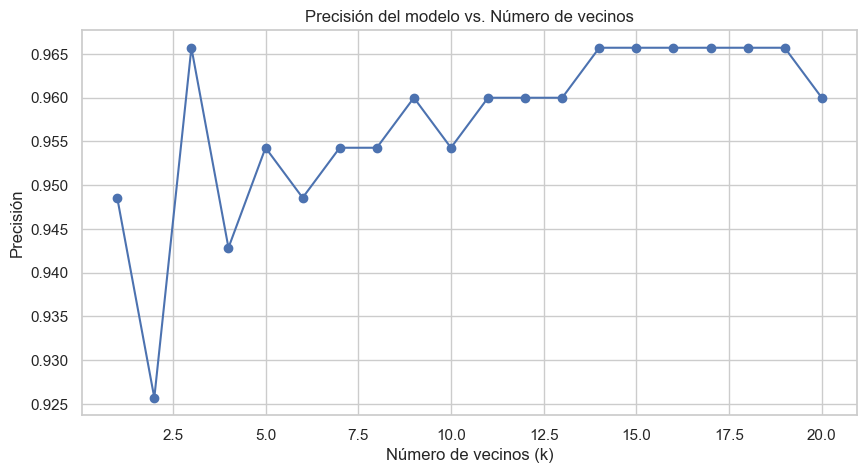

Mejor valor de k: 3


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Probar diferentes valores de k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Gráfico de precisión vs k
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión')
plt.title('Precisión del modelo vs. Número de vecinos')
plt.show()

# k óptimo
best_k = k_values[np.argmax(accuracies)]
print(f"Mejor valor de k: {best_k}")


Paso 3: Métricas de evaluación del mejor modelo

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Modelo final con mejor k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Matriz de confusión y reporte
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Matriz de Confusión:
[[111   4]
 [  2  58]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           2       0.98      0.97      0.97       115
           4       0.94      0.97      0.95        60

    accuracy                           0.97       175
   macro avg       0.96      0.97      0.96       175
weighted avg       0.97      0.97      0.97       175



# Parte C: Balanceo de clases con SMOTE

Paso 1: Aplicar SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Distribución de clases después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())


Distribución de clases después de SMOTE:
Class
2    343
4    343
Name: count, dtype: int64


Paso 2: Entrenar y evaluar modelo k-NN con datos balanceados

In [14]:
knn_smote = KNeighborsClassifier(n_neighbors=best_k)
knn_smote.fit(X_train_bal, y_train_bal)
y_pred_smote = knn_smote.predict(X_test_scaled)

# Métricas del modelo balanceado
print("Matriz de Confusión (SMOTE):")
print(confusion_matrix(y_test, y_pred_smote))

print("\nReporte de Clasificación (SMOTE):")
print(classification_report(y_test, y_pred_smote))


Matriz de Confusión (SMOTE):
[[111   4]
 [  1  59]]

Reporte de Clasificación (SMOTE):
              precision    recall  f1-score   support

           2       0.99      0.97      0.98       115
           4       0.94      0.98      0.96        60

    accuracy                           0.97       175
   macro avg       0.96      0.97      0.97       175
weighted avg       0.97      0.97      0.97       175

